In [1]:
path = '/kaggle/input/datasets/almutalem/rehab24-6/REHAB24-6'

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import os

The raw `.npy` files only contain isolated spatial coordinates without any structural metadata. To visualize the data as recognizable human figure we must manually define `edges/bones`, by referencing `joints_names.txt`.

In [3]:
# Mapping of the bones and joints to make the 2D skeleton

BONES = [
    (0, 1), (1, 2), (2, 3), (3, 4), (4, 5),
    (2, 6), (6, 7), (7, 8), (8, 9), (9, 10),
    (2, 11), (11, 12), (12, 13), (13, 14), (14, 15),
    (0, 16), (16, 17), (17, 18), (18, 19), (19, 20),
    (0, 21), (21, 22), (22, 23), (23, 24), (24, 25)
]

In [4]:
joint_names = [line.split(':')[1].strip() for line in open(f'{path}/joints_names.txt') if ':' in line]
marker_names = [line.split(':')[1].strip() for line in open(f'{path}/marker_names.txt') if ':' in line]

The dataset utilizes two orthogonally placed cameras with different native orientations.
- C17: Mounted horizontally (Landscape), resulting in wider X-coordinates.
- C18: Mounted vertically (Portrait), resulting in deeper Y-coordinates.

In [5]:
def plot_2d_dynamic(joints_2d, markers_2d, frame_idx=0):
    """Dynamically sizes the canvas based on the camera's orientation."""
    j2d = joints_2d[frame_idx]
    m2d = markers_2d[frame_idx]
    
    # 1. Dynamically find the required canvas size based on the data
    # We add 100 pixels of "padding" so the skeleton doesn't touch the very edge
    max_x = int(max(np.max(j2d[:, 0]), np.max(m2d[:, 0]))) + 100
    max_y = int(max(np.max(j2d[:, 1]), np.max(m2d[:, 1]))) + 100
    
    # Create the perfectly sized black canvas (Height x Width)
    canvas = np.zeros((max_y, max_x, 3), dtype=np.uint8)
    
    # 2. Draw Bones (Yellow Lines)
    for bone in BONES:
        pt1 = (int(j2d[bone[0]][0]), int(j2d[bone[0]][1]))
        pt2 = (int(j2d[bone[1]][0]), int(j2d[bone[1]][1]))
        cv2.line(canvas, pt1, pt2, color=(0, 255, 255), thickness=2, lineType=cv2.LINE_AA)
        
    # 3. Draw 26 Joints (Red Circles)
    for pt in j2d:
        center = (int(pt[0]), int(pt[1]))
        cv2.circle(canvas, center, radius=6, color=(0, 0, 255), thickness=-1, lineType=cv2.LINE_AA)

    # 4. Draw 41 Markers (Green Circles)
    for pt in m2d:
        center = (int(pt[0]), int(pt[1]))
        cv2.circle(canvas, center, radius=4, color=(0, 255, 0), thickness=-1, lineType=cv2.LINE_AA)

    # Convert BGR (OpenCV) to RGB (Matplotlib)
    canvas_rgb = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)

    # Display in Kaggle
    plt.figure(figsize=(8, 10))
    plt.imshow(canvas_rgb)
    plt.axis('off')
    plt.title(f"2D Projection - Dynamic Canvas (Frame {frame_idx})")
    plt.show()

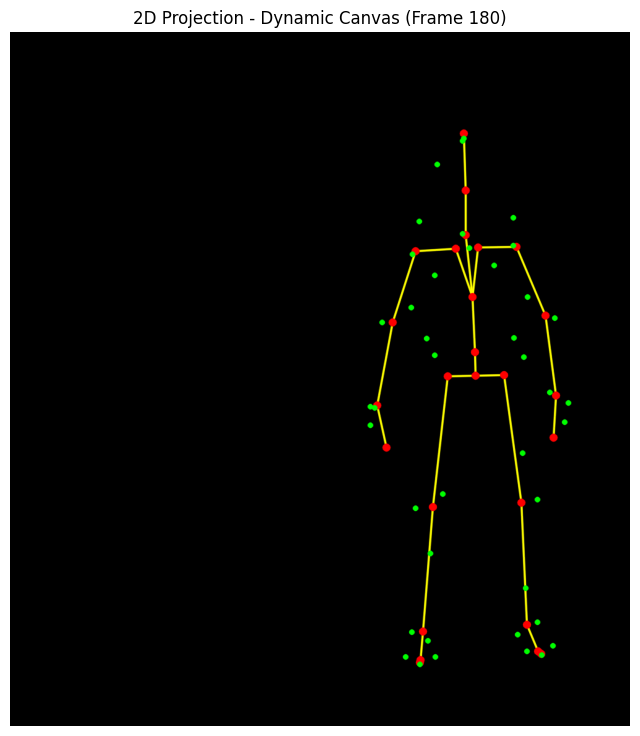

In [6]:
joint_data_front = np.load(f'{path}/2d_joints/Ex1/PM_000-c17-30fps.npy')
marker_data_front = np.load(f'{path}/2d_markers/Ex1/PM_000-c17-30fps.npy')
plot_2d_dynamic(joint_data_front, marker_data_front, frame_idx=180)

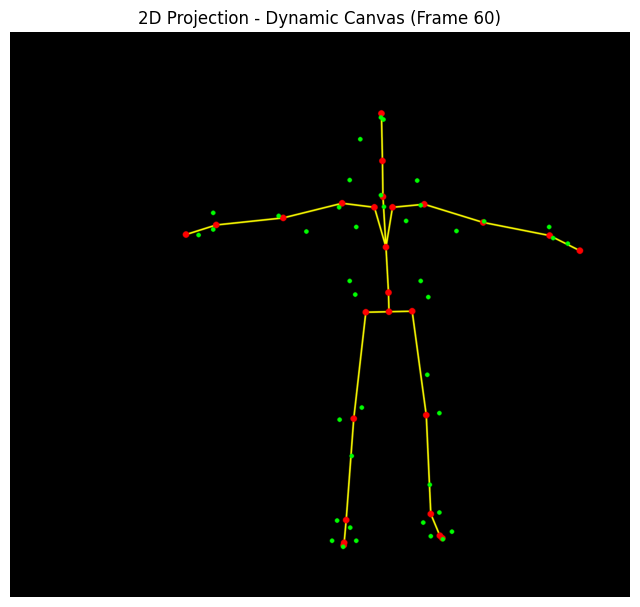

In [9]:
joint_data_front = np.load(f'{path}/2d_joints/Ex1/PM_000-c17-30fps.npy')
marker_data_front = np.load(f'{path}/2d_markers/Ex1/PM_000-c17-30fps.npy')
plot_2d_dynamic(joint_data_front, marker_data_front, frame_idx=60)

### Visualizing C17 (Horizontal Camera)
Extracting Frame 180 & 60 from the C17 camera reveals the front-facing profile of the subject. The red internal joints and green surface markers align perfectly, verifying that the 3D-to-2D pinhole projection calibration provided in the dataset is accurate.

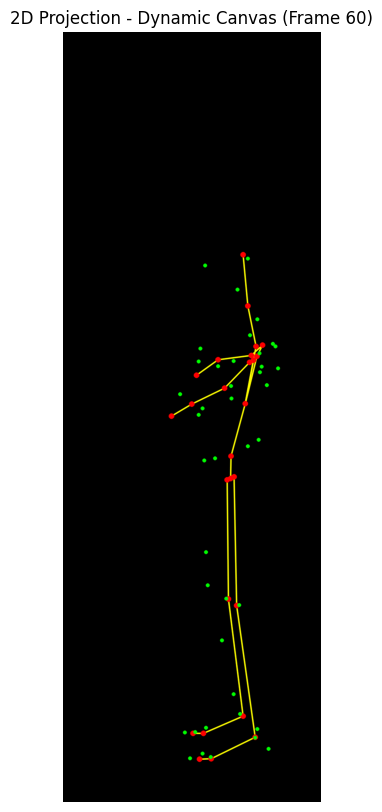

In [8]:
joint_data_side = np.load(f'{path}/2d_joints/Ex1/PM_000-c18-30fps.npy')
marker_data_side = np.load(f'{path}/2d_markers/Ex1/PM_000-c18-30fps.npy')
plot_2d_dynamic(joint_data_side, marker_data_side, frame_idx=60)

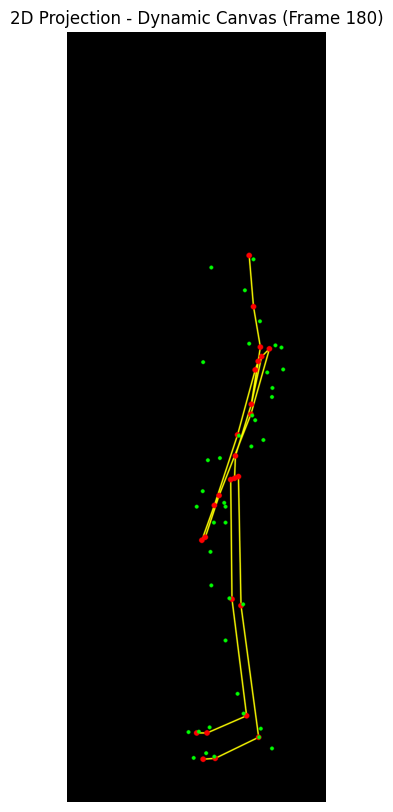

In [7]:
joint_data_side = np.load(f'{path}/2d_joints/Ex1/PM_000-c18-30fps.npy')
marker_data_side = np.load(f'{path}/2d_markers/Ex1/PM_000-c18-30fps.npy')
plot_2d_dynamic(joint_data_side, marker_data_side, frame_idx=180)

### Visualizing C18 (Vertical Camera)
Extracting the exact same frames from the C18 camera reveals the side profile. Because the cameras are perfectly synchronized, we can observe the exact same millisecond of movement from a 90-degree offset.